In [1]:
import importlib
import peak_gene_utils
importlib.reload(peak_gene_utils)
from peak_gene_utils import *

from utils import *
import squidpy as sq

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

## Load data

In [2]:
# Load cCREs as a DataFrame
ccre_bed = pd.read_csv(
    "mm10-cCREs.bed",
    sep="\t",
    header=None,
    names=["chrom", "start", "end", "ccre_id", "accession", "ccre_type"]
)

In [4]:
promoter_ccres = ccre_bed[ccre_bed["ccre_type"]=="PLS"]

In [5]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [6]:
sp_merfish = sc.read_h5ad("../../h5ad_files/c_sp_ad.h5ad")

In [7]:
sp_merfish_names = sp_merfish.var.index.str.lower().tolist()

In [8]:
data = np.load("cached_data.npz")
idx_atac = data["idx_atac"]
idx_expr = data["idx_expr"]
pdist_ = data["pdist"]

In [9]:
atac_20000 = atac[:,idx_atac]
expr_2000 = expr[:,idx_expr]

In [10]:
g_p_similarity = pdist_[20000:,:20000]

In [11]:
sq.gr.spatial_autocorr(expr_2000, mode="moran")

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  obj[key] = data


In [12]:
sq.gr.spatial_autocorr(atac_20000, mode="moran")

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  obj[key] = data


In [13]:
moran_list = expr_2000.uns["moranI"].head(n=250).index.tolist()

In [14]:
peak_moran_list = atac_20000.uns["moranI"].head(n=1000).index.tolist()

## Get correlated gene-peak pairs

In [15]:
# Get only unannotated peaks near genes in moran_list
no_anno_results_by_gene = get_filtered_peak_results_by_gene(
    gene_list=expr_2000.var_names,
    expr=expr_2000,
    atac=atac_20000,
    g_p_similarity=g_p_similarity,
    ccre_bed=ccre_bed,
    top_n=200,
    max_distance=150000,
    keep_annotated=False
)

Skipping gm11128: Coordinates missing for gene gm11128.
Skipping a330050f15rik: Coordinates missing for gene a330050f15rik.
Skipping rp23-474j16.2: Coordinates missing for gene rp23-474j16.2.
Skipping rp24-136l4.6: Coordinates missing for gene rp24-136l4.6.
Skipping rp23-2d23.2: Coordinates missing for gene rp23-2d23.2.
Skipping pcnxl2: Coordinates missing for gene pcnxl2.
Skipping mir143hg: Coordinates missing for gene mir143hg.
Skipping rp24-416m6.5: Coordinates missing for gene rp24-416m6.5.
Skipping rp24-267c3.3: Coordinates missing for gene rp24-267c3.3.
Skipping rp24-134n2.1: Coordinates missing for gene rp24-134n2.1.
Skipping rp23-407n2.2: Coordinates missing for gene rp23-407n2.2.
Skipping pvrl3: Coordinates missing for gene pvrl3.
Skipping creb5: Coordinates missing for gene creb5.
Skipping rp24-263g24.2: Coordinates missing for gene rp24-263g24.2.
Skipping rp23-44h21.1: Coordinates missing for gene rp23-44h21.1.


In [16]:
# Get only annotated peaks
anno_results_by_gene = get_filtered_peak_results_by_gene(
    gene_list=moran_list,
    expr=expr_2000,
    atac=atac_20000,
    g_p_similarity=g_p_similarity,
    ccre_bed=ccre_bed,
    top_n=200,
    max_distance=150000,
    keep_annotated=True
)

Skipping mir143hg: Coordinates missing for gene mir143hg.


In [17]:
anno_results_by_peak = get_genes_associated_with_peaks(
    peak_names=peak_moran_list,
    expr=expr_2000,
    atac=atac_20000,
    g_p_similarity=g_p_similarity,
    ccre_bed=ccre_bed,
    keep_annotated=True,   # or False, or None to skip
    max_distance=150000,
    top_n_per_peak=10
)

In [18]:
no_anno_results_by_peak = get_genes_associated_with_peaks(
    peak_names=peak_moran_list,
    expr=expr_2000,
    atac=atac_20000,
    g_p_similarity=g_p_similarity,
    ccre_bed=ccre_bed,
    keep_annotated=False,   # or False, or None to skip
    max_distance=150000,
    top_n_per_peak=10
)

## Plot pairs (reduced to 10 pairs for now)

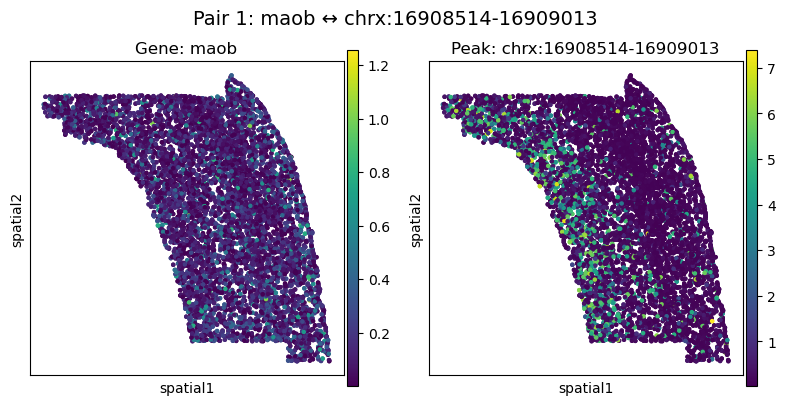

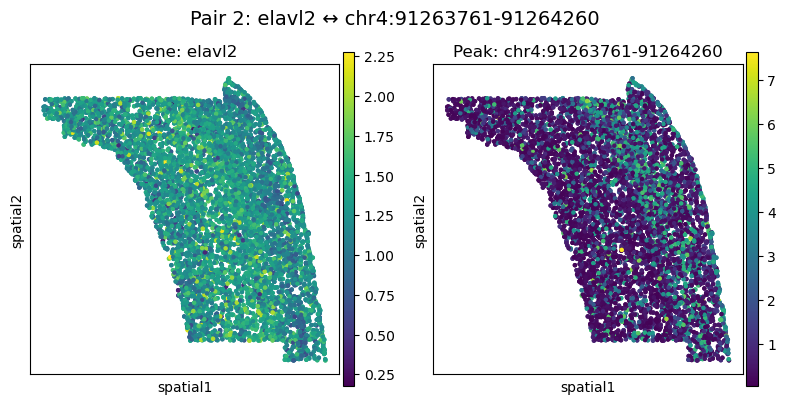

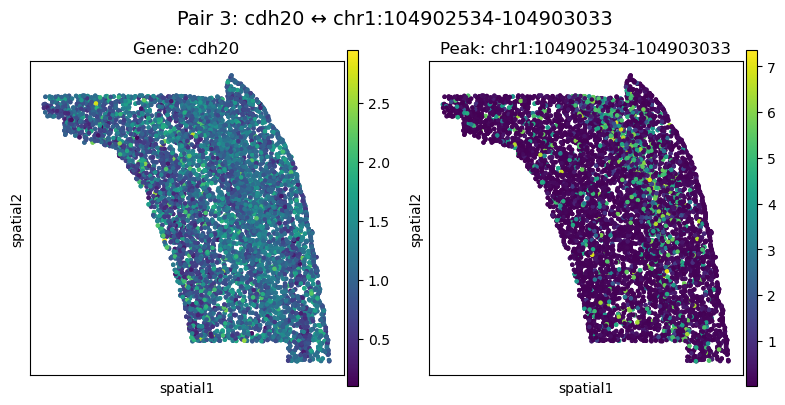

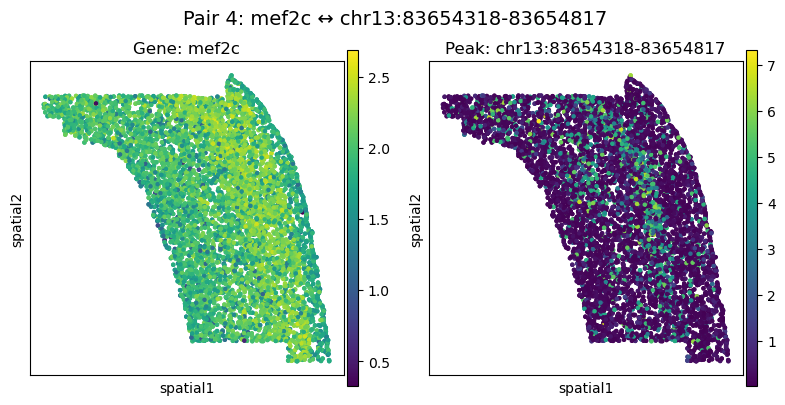

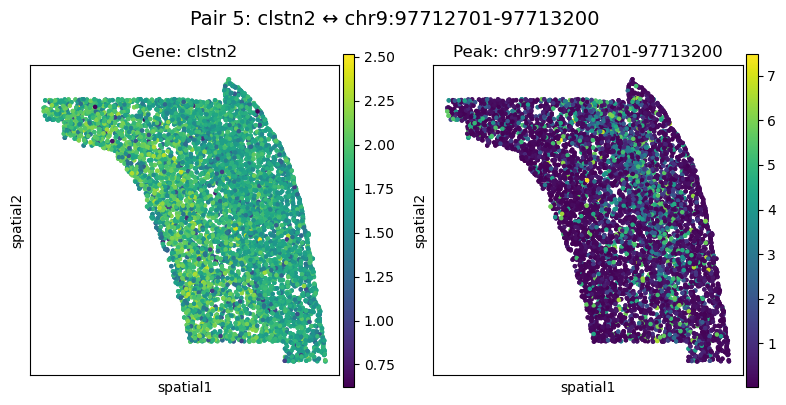

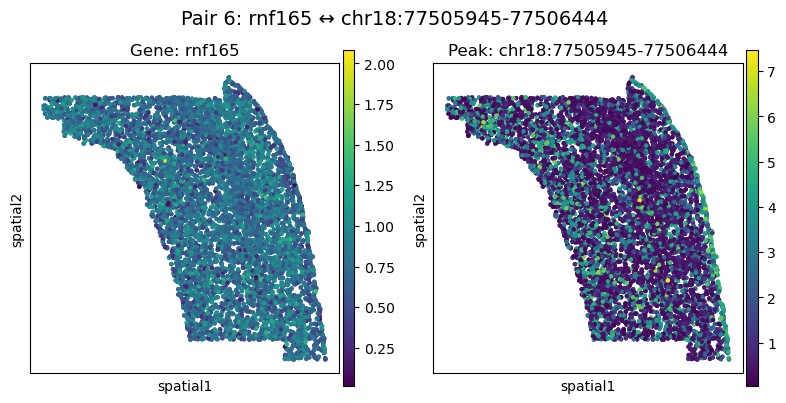

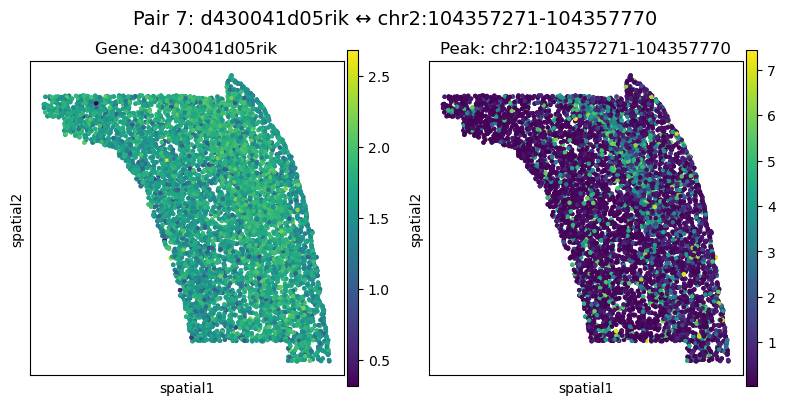

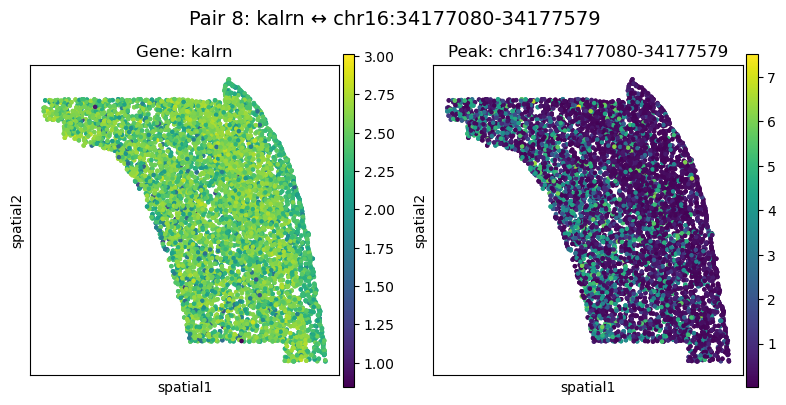

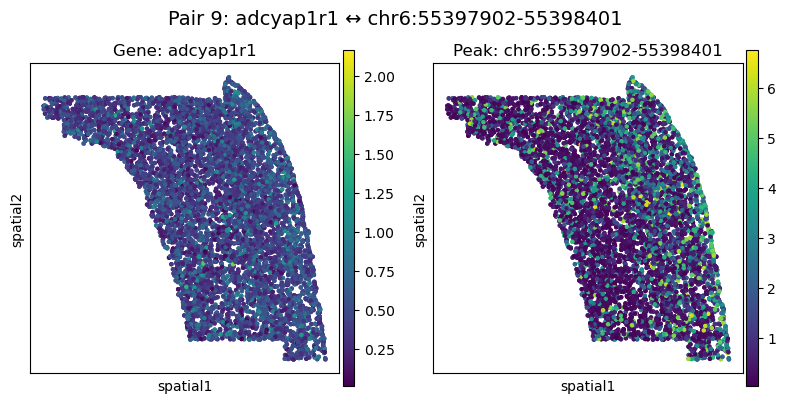

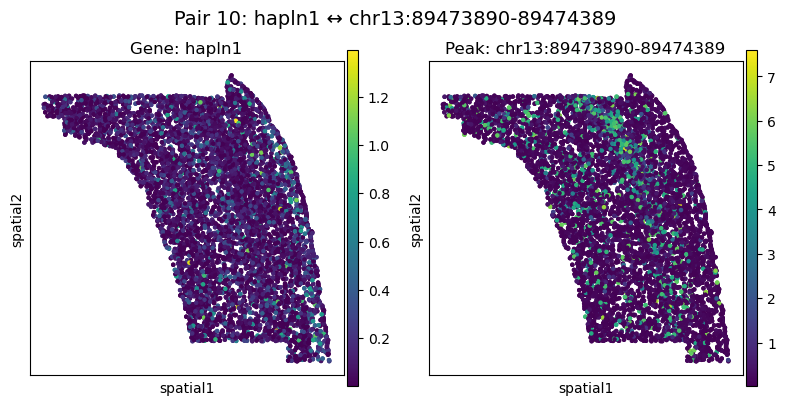

In [19]:
plot_peak_gene_pairs(
    mapping_dict=no_anno_results_by_peak,
    expr_adata=expr_2000,
    atac_adata=atac_20000,
    mode='peak_to_gene',
    n_pairs=10
)

plot_peak_gene_pairs(
    mapping_dict=anno_results_by_peak,
    expr_adata=expr_2000,
    atac_adata=atac_20000,
    mode='peak_to_gene',
    n_pairs=10
)

plot_peak_gene_pairs(
    mapping_dict=anno_results_by_gene,
    expr_adata=expr_2000,
    atac_adata=atac_20000,
    mode='gene_to_peak',
    n_pairs=10
)

In [20]:
len(no_anno_results_by_gene) + len(no_anno_results_by_peak) + len(anno_results_by_gene) + len(anno_results_by_peak)

372

plot_peak_gene_pairs(
    mapping_dict=no_anno_results_by_gene,
    expr_adata=expr_2000,
    atac_adata=atac_20000,
    mode='gene_to_peak',
    n_pairs=10
)

## Peak-Peak correlations

look for peaks correlated to promoter (PLS) peaks

### combine annotated Peaks from both mappings

In [21]:
# Flatten all peak rows into one DataFrame
p_by_g_df = pd.concat(anno_results_by_gene.values())
p_by_g_df = p_by_g_df[["chrom", "start", "end"]].drop_duplicates()

# Step 1: find promoter-overlapping peaks
by_g_promoter_peaks = get_promoter_overlapping_peaks(p_by_g_df, promoter_ccres=promoter_ccres)

In [22]:
by_p_list = list(anno_results_by_peak.keys())
g_by_p_df = atac_20000.var.loc[by_p_list, ["chrom", "start", "end"]]  # or your peak dataframe

# Get promoter overlaps
by_p_promoter_peaks = get_promoter_overlapping_peaks(g_by_p_df, promoter_ccres)

In [23]:
promoter_union_peaks = list(set(by_g_promoter_peaks) | set(by_p_promoter_peaks))

In [24]:
len(promoter_union_peaks)

29

In [25]:
# get peak-peak similarity matrix
p_p_similarity = pdist_[:20000, :20000]

In [ ]:
promoter_correlated_peaks = get_correlated_peaks_near_peaks(
    peak_names=promoter_union_peaks,
    atac=atac_20000,
    p_p_similarity=p_p_similarity,
    max_distance=100000,
    top_n_per_peak=10
)

In [ ]:
len(promoter_correlated_peaks)

## Celltype specific analysis

Get all genes correlated with at least one peak

In [ ]:
# Flatten values from *_by_peak (each value is a list of genes)
genes_from_anno_by_peak = {gene for genes in anno_results_by_peak.values() for gene in genes}
genes_from_no_anno_by_peak = {gene for genes in no_anno_results_by_peak.values() for gene in genes}

# Union all gene names from all sources
all_genes = set(no_anno_results_by_gene.keys()) | \
            set(anno_results_by_gene.keys()) | \
            genes_from_anno_by_peak | \
            genes_from_no_anno_by_peak

# Optionally sort
all_genes = sorted(all_genes)

# Convert gene list to a set for efficient comparison
all_genes_set = set(all_genes)

In [ ]:
len(all_genes)

In [ ]:
# optionally: only w/ CRE annotation
# Flatten values from *_by_peak (each value is a list of genes)
'''
genes_from_anno_by_peak = {gene for genes in anno_results_by_peak.values() for gene in genes}

# Union all gene names from all sources
all_genes = set(anno_results_by_gene.keys()) | \
            genes_from_anno_by_peak

# Optionally sort
all_genes = sorted(all_genes)
'''

### find marker genes independently on scRNA SHARE-seq data

In [ ]:
ad_sc = sc.read_h5ad("../../h5ad_files/c_sc_ad.h5ad")

ad_sc.var_names = ad_sc.var_names.str.lower()

sc.tl.rank_genes_groups(ad_sc, groupby="celltype")

In [ ]:
# Extract top 100 marker genes per subclass
marker_genes_df = sc.get.rank_genes_groups_df(ad_sc, group=None, key='rank_genes_groups', pval_cutoff=0.05)

In [ ]:
# Keep top 100 genes per subclass (cell type)
top10_per_subclass = marker_genes_df.groupby("group").head(10)

In [ ]:
sc.pl.rank_genes_groups(ad_sc)

In [ ]:
# Find overlapping genes between all_genes and marker genes
overlapping_genes = all_genes_set.intersection(top10_per_subclass['names'])
print(f"Number of overlapping genes: {len(overlapping_genes)}")

In [ ]:
sq.pl.spatial_scatter(shape=None, adata=expr, color=overlapping_genes)

#### looking at rorb (also look at cux2, marker for L4/EN04)

In [ ]:
top10_per_subclass[top10_per_subclass["names"]=="rorb"]

rorb is correlated with peak chr19:18972253-18972752

In [ ]:
get_overlapping_ccres("chr19:18972253-18972752", ccre_bed)

In [ ]:
rorb_corr_peaks = get_correlated_peaks_near_peaks(
    peak_names=["chr19:18972253-18972752"],
    atac=atac_20000,
    p_p_similarity=p_p_similarity,
    max_distance=100000,
    top_n_per_peak=5
)

In [ ]:
rorb_corr_peaks

In [ ]:
get_overlapping_ccres('chr19:18967342-18967841', ccre_bed)

In [ ]:
plot_peak_peak_pairs({"chr19:18972253-18972752": ["chr19:18967342-18967841"]}, atac_adata=atac_20000)

#### looking for genes correlated with promoter peaks

In [ ]:
marker_genes = set(top10_per_subclass['names'].str.lower())

In [ ]:
len(marker_genes)

**Finding promoter peaks correlated with marker genes**

In [ ]:
def find_matching_peaks(peak_to_genes_dict, promoter_union_peaks, marker_genes):
    return {
        peak for peak, genes in peak_to_genes_dict.items()
        if peak in promoter_union_peaks and any(g.lower() in marker_genes for g in genes)
    }

##### get promoter peaks from gene -> peak mapping

In [ ]:
def find_matching_peaks_from_gene(gene_to_result_dict, promoter_union_peaks, marker_genes):
    matching_peaks = set()
    for gene, df in gene_to_result_dict.items():
        gene_lc = gene.lower()
        if gene_lc in marker_genes:
            peaks = df.index if isinstance(df, pd.DataFrame) else []
            matching_peaks.update(p for p in peaks if p in promoter_union_peaks)
    return matching_peaks

In [ ]:
matching_peaks_anno = find_matching_peaks(anno_results_by_peak, promoter_union_peaks, marker_genes)
matching_peaks_anno_gene = find_matching_peaks_from_gene(anno_results_by_gene, promoter_union_peaks, marker_genes)

# Combine if you want the full set
matching_promoter_peaks = matching_peaks_anno | matching_peaks_anno_gene

In [ ]:
len(matching_promoter_peaks)

In [ ]:
matching_promoter_peaks

**Finding promoter peaks correlated with any gene (not constrained to marker genes)**

In [ ]:
promo_peak_not_constrained_to_marker_by_gene = find_matching_peaks_from_gene(anno_results_by_gene, promoter_union_peaks, all_genes)

In [ ]:
promo_peak_not_constrained_to_marker_by_peak = find_matching_peaks(anno_results_by_peak, promoter_union_peaks, all_genes)

In [ ]:
promoter_peaks_not_constrained_to_marker = promo_peak_not_constrained_to_marker_by_gene | promo_peak_not_constrained_to_marker_by_peak

In [ ]:
len(promoter_peaks_not_constrained_to_marker)

In [ ]:
genes_all_corr_with_promo_peaks = get_genes_associated_with_peaks(
    peak_names=promoter_peaks_not_constrained_to_marker,
    expr=expr_2000,
    atac=atac_20000,
    g_p_similarity=g_p_similarity,
    ccre_bed=ccre_bed,
    keep_annotated=True,   # or False, or None to skip
    max_distance=150000,
    top_n_per_peak=10
)

In [ ]:
len(genes_all_corr_with_promo_peaks)

In [ ]:
list_genes_all_corr_with_promo_peaks = []
for li in genes_all_corr_with_promo_peaks.values():
    for g in li:
        list_genes_all_corr_with_promo_peaks.append(g)

### Promoter peaks corr. mit genes (not constrained to marker genes)
interessant:  
- 'chr7:51510836-51511335': ['slc17a6'], (geht)
-  'chr4:8238644-8239143': ['car8'], (car8 auch marker)
- 'chr9:8543939-8544438': ['trpc6'],
- 'chr5:31201463-31201962': ['slc30a3'],
- 'chr7:45163560-45164059': ['slc17a7'
- 'chr1:181353030-181353529': ['cnih3']

In [ ]:
gene_promo_peak_pairs_not_constrained_to_markers = {
    'chr7:51510836-51511335': ['slc17a6'],
    'chr4:8238644-8239143': ['car8'],
    'chr9:8543939-8544438': ['trpc6'],
    'chr5:31201463-31201962': ['slc30a3'],
    #'chr7:45163560-45164059': ['slc17a7'],
    'chr1:181353030-181353529': ['cnih3'],
}

In [ ]:
plot_peak_gene_pairs(mapping_dict=gene_promo_peak_pairs_not_constrained_to_markers, mode="peak_to_gene", expr_adata=expr_2000, atac_adata=atac_20000, n_pairs=100)

look for just proximal peaks near car8 PLS peak

In [ ]:
get_overlapping_ccres('chr4:8238644-8239143', ccre_bed)

In [ ]:
car8_corr_peaks = get_correlated_peaks_near_peaks(
    peak_names=["chr4:8238644-8239143"],
    atac=atac_20000,
    p_p_similarity=p_p_similarity,
    max_distance=150000,
    top_n_per_peak=5
)

In [ ]:
for p in car8_corr_peaks['chr4:8238644-8239143']:
    print(p)
    print(get_overlapping_ccres(p, ccre_bed))

In [ ]:
print(get_overlapping_ccres("chr4:8374709-8375208", ccre_bed))

In [ ]:
top10_per_subclass[top10_per_subclass["names"]=="car8"]

In [ ]:
sq.pl.spatial_scatter(shape=None, adata=expr, color="car8")

car8 und rorb

In [ ]:
plot_peak_gene_pairs(
    mapping_dict={"chr4:8238644-8239143": ["car8"]},
    expr_adata=expr_2000,
    atac_adata=atac_20000,
    mode='peak_to_gene',
    n_pairs=10
)

In [ ]:
plot_peak_peak_pairs(
    mapping_dict=car8_corr_peaks,
    atac_adata=atac_20000,
    n_pairs=10,
    size=25
)

### focus on two genes: rorb and car8
rorb is marker, doesnt have corr promoter

car8 is marker, has corr promoter

auch:
    'chr7:51510836-51511335': ['slc17a6'],
    'chr9:8543939-8544438': ['trpc6'],
    'chr1:181353030-181353529': ['cnih3'],